## 딥러닝

### 심층신경망

In [7]:
# 모듈 로드
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


In [4]:
# 훈련세트, 검증세트 분리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
train_input = train_input.reshape(-1, 28*28)
test_input = test_input.reshape(-1, 28*28)

In [8]:
# 스케일링
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_input.astype(np.float64))
test_scaled = scaler.transform(test_input.astype(np.float64))

In [9]:
# 훈련세트, 검증세트 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [11]:
print(train_scaled.shape, test_scaled.shape, test_scaled.shape)
print(train_target.shape, val_target.shape, test_target.shape)

(48000, 784) (10000, 784) (10000, 784)
(48000,) (12000,) (10000,)


#### 심층신경망 만들기1

In [19]:
dense1 = keras.layers.Dense(100, activation='sigmoid', input_shape=(784,), name='hidden')
dense2 = keras.layers.Dense(10, activation='softmax', name='output')

In [13]:
# 신경망 모델 생성
model = keras.Sequential([dense1, dense2])

In [16]:
# 모델 요약
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               78500     
                                                                 
 dense_1 (Dense)             (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### 심층신경망 만들기2

In [26]:
model = keras.Sequential([
    keras.layers.Dense(100, activation='sigmoid', input_shape=(784,), name='hidden'),
    keras.layers.Dense(10, activation='softmax', name='output')
], name='Fashion_MNIST_Model')

In [27]:
model.summary()

Model: "Fashion_MNIST_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden (Dense)              (None, 100)               78500     
                                                                 
 output (Dense)              (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [28]:
# 모델 훈련 전 설정
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')

In [29]:
# 훈련
model.fit(train_scaled, train_target, epochs=100)

Epoch 1/100


1500/1500 [==============================] - 2s 1ms/step - loss: 0.4696 - accuracy: 0.8365
Epoch 2/100
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3563 - accuracy: 0.8721
Epoch 3/100
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3198 - accuracy: 0.8846
Epoch 4/100
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2956 - accuracy: 0.8939
Epoch 5/100
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2745 - accuracy: 0.9006
Epoch 6/100
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2574 - accuracy: 0.9074
Epoch 7/100
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2433 - accuracy: 0.9135
Epoch 8/100
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2290 - accuracy: 0.9178
Epoch 9/100
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2171 - accuracy: 0.9224
Epoch 10/100
1500/1500 [==============================] - 2s 1ms/step -

In [ ]:
model.evaluate(val_scaled, val_target)
# 검증 정확도 : 87.8%

375/375 [==============================] - 0s 949us/step - loss: 0.8783 - accuracy: 0.8733


[0.878257155418396, 0.8732500076293945]

In [36]:
pred_result = model.predict(test_scaled)

313/313 [==============================] - 0s 824us/step


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [33]:
# 한글로 Matplotlib 사용시 항상 필요
from matplotlib import rcParams, font_manager, rc

font_path = 'C:/Windows/Fonts/malgun.ttf'
font = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font)
rcParams['axes.unicode_minus'] = False

sns.set_style('darkgrid')
sns.set_theme(font='Malgun Gothic', rc={'axes.unicode_minus': False})

In [45]:
class_names = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵클부츠']

In [46]:
# 테스트이미지와 예측결과 시각화
def show_image(index):
    plt.figure(figsize=(2,2))
    plt.imshow(test_input[index].reshape(28, 28), cmap='gray_r')
    true_label = class_names[test_target[index]]
    pred_label = class_names[np.argmax(pred_result[index])]
    plt.title(f'실제: {true_label}, 예측: {pred_label}')
    plt.axis('off')
    plt.show()

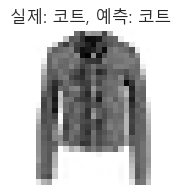

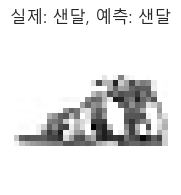

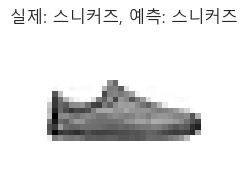

In [48]:
for i in range(10, 13):
    show_image(i)

#### 렐루 함수

- 초기에는 인공신경망 은닉층에 Sigmoid 함수 사용
    - 단점 : 오른쪽, 왼쪽 끝으로 갈수록 그래프가 누워있어서 올바른 출력을 못 만듦

- 렐루함수(ReLU) : 수정된 선형유닛이라는 뜻의 함수

    <img src="../image/ml011.png" width="500">

#### Flatten 객체
- 이미지 2차원 배열을 1차원으로 변경할 때 np.reshape() 사용
- Flatten 클래스가 위의 일을 대신해줌

In [49]:
model2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28), name='Flatten'),
    keras.layers.Dense(100, activation='relu', name='Hidden'),
    keras.layers.Dense(10, activation='softmax', name='Output')
], name='Fashion_MNIST_RELU')

In [50]:
model2.summary()

Model: "Fashion_MNIST_RELU"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Flatten (Flatten)           (None, 784)               0         
                                                                 
 Hidden (Dense)              (None, 100)               78500     
                                                                 
 Output (Dense)              (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [51]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [53]:
train_scaled = train_input / 255.0
test_scaled = test_input / 255.0

In [54]:
# 훈련세트, 검증세트 분리
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [55]:
# 모델 설정
model2.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')

In [56]:
# 모델 훈련
model2.fit(train_scaled, train_target, epochs=20)

Epoch 1/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.5260 - accuracy: 0.8143
Epoch 2/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3903 - accuracy: 0.8600
Epoch 3/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3541 - accuracy: 0.8720
Epoch 4/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3317 - accuracy: 0.8825
Epoch 5/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3157 - accuracy: 0.8857
Epoch 6/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3025 - accuracy: 0.8923
Epoch 7/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2954 - accuracy: 0.8950
Epoch 8/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2860 - accuracy: 0.8980
Epoch 9/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2773 - accuracy: 0.9012
Epoch 10/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.271

In [ ]:
model2.evaluate(val_scaled, val_target)
# ReLU함수 사용시, Sigmoid함수 사용시 0.01% 개선

375/375 [==============================] - 0s 894us/step - loss: 0.4219 - accuracy: 0.8823


[0.4218914806842804, 0.8822500109672546]

#### 옵티마이저
- 하이퍼파라미터 값 최적화

In [58]:
model3 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28), name='Flatten'),
    keras.layers.Dense(100, activation='relu', name='Hidden'),
    keras.layers.Dense(10, activation='softmax', name='Output')
], name='Fashion_MNIST_RELU')

In [ ]:
# 모델3 설정, 최적화는 adam클래스만 사용할 것
model3.compile(loss='sparse_categorical_crossentropy', metrics='accuracy', optimizer='adam')

In [ ]:
model3.fit(train_scaled, train_target, epochs=20)

Epoch 1/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.5300 - accuracy: 0.8166
Epoch 2/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3967 - accuracy: 0.8593
Epoch 3/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3534 - accuracy: 0.8729
Epoch 4/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3256 - accuracy: 0.8807
Epoch 5/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3062 - accuracy: 0.8875
Epoch 6/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2896 - accuracy: 0.8927
Epoch 7/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2772 - accuracy: 0.8973
Epoch 8/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2659 - accuracy: 0.9005
Epoch 9/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2572 - accuracy: 0.9051
Epoch 10/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.247

- optimizer 사용 시 0.01정도 개선

In [61]:
model3.evaluate(val_scaled, val_target)

375/375 [==============================] - 0s 957us/step - loss: 0.3508 - accuracy: 0.8867


[0.3508267104625702, 0.8866666555404663]

#### 드롭아웃
- 훈련과정 밀집층 일부 뉴런을 꺼버림

In [62]:
model4 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28), name='Flatten'),
    keras.layers.Dense(100, activation='relu', name='Hidden'),
    keras.layers.Dropout(0.3, name='Dropout'),
    keras.layers.Dense(10, activation='softmax', name='Output')
], name='Fashion_MNIST_RELU')

In [63]:
model4.summary()

Model: "Fashion_MNIST_RELU"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Flatten (Flatten)           (None, 784)               0         
                                                                 
 Hidden (Dense)              (None, 100)               78500     
                                                                 
 Dropout (Dropout)           (None, 100)               0         
                                                                 
 Output (Dense)              (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [64]:
# 모델4 설정, 최적화는 adam클래스만 사용할 것
model4.compile(loss='sparse_categorical_crossentropy', metrics='accuracy', optimizer='adam')

In [65]:
model4.fit(train_scaled, train_target, epochs=20)

Epoch 1/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.5954 - accuracy: 0.7916
Epoch 2/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.4381 - accuracy: 0.8419
Epoch 3/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.4044 - accuracy: 0.8522
Epoch 4/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3817 - accuracy: 0.8621
Epoch 5/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3694 - accuracy: 0.8657
Epoch 6/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3539 - accuracy: 0.8710
Epoch 7/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3445 - accuracy: 0.8729
Epoch 8/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3346 - accuracy: 0.8762
Epoch 9/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.3289 - accuracy: 0.8780
Epoch 10/20
1500/1500 [==============================] - 2s 1ms/step - loss: 0.320

#### 결론
- `심층신경망` : 2개 이상의 밀집층을 포함한 신경망 모델. 다층 인공신경망
- `렐루함수` : 시그모이드 함수의 단점을 보완한 활성화 함수
- `옵티마이저` : 신경망의 가중치(기울기)와 절편을 학습하기 위한 알고리즘 또는 방법. `Adam`, SGD(활률적 경사하강법), RMSprop...